In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn import linear_model
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [111]:
#read in training data
train_data = pd.read_csv("train_data.csv", delimiter = ";")

df = pd.DataFrame(train_data)
y_split = df["wb_overall_mean"]


#extract relevant features from training data
train_data = train_data[["rel_1","rel_2","rel_3","rel_4","rel_5",
                         "rel_6","rel_7","rel_8","rel_9","cnorm_1",
                         "cnorm_2","age","gender","ethnicity","ses","denomination","education"]]
#encode dummy variables of categorical data
train_data_dummies = pd.get_dummies(train_data)

#split training data to create validation data
x_train, x_test, y_train, y_test = train_test_split(train_data_dummies, y_split, test_size = 0.2, random_state = 42)


In [112]:
train_data_dummies

,rel_1,rel_2,rel_3,rel_4,rel_5,rel_6,rel_7,rel_8,rel_9,cnorm_1,cnorm_2,age,ses,education,gender_man,gender_other,gender_woman,ethnicity_African,ethnicity_Armenian,ethnicity_Asian,ethnicity_Caucasian/European,ethnicity_Chinese,ethnicity_East Asian,ethnicity_I would rather not say,ethnicity_Indian,ethnicity_Indigenous,ethnicity_Kurdish,ethnicity_Latin-American,ethnicity_Malay,ethnicity_Middle-Eastern/Arab,ethnicity_Mixed / other,ethnicity_Pacific Islander,ethnicity_South Asian,ethnicity_Turkish,denomination_African religions,denomination_Buddhist,denomination_Christian,denomination_Christian (Orthodox - Russian/Greek/etc.),denomination_Christian (Protestant),denomination_Christian (Roman Catholic),denomination_Druze,denomination_Evangelical,denomination_Hindu,denomination_Jain,denomination_Jewish,denomination_Muslim,denomination_Muslim (Alevi),denomination_Muslim (Azhari),denomination_Muslim (Sunni),denomination_Muslim (non-sectarian),denomination_Other:,denomination_Shinto,denomination_Spiritist,denomination_Taoist
0,0.833333,0.857143,1.0,1,0.833333,0.833333,1.000000,1.00,1.00,0.75,1.00,20.0,6.0,4,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,0.000000,0.000000,0.0,0,0.166667,0.166667,0.166667,0.00,0.00,0.50,0.50,22.0,5.0,3,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,0.000000,0.000000,0.5,0,0.000000,0.500000,0.000000,0.00,0.00,0.75,0.75,42.0,6.0,5,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,0.500000,0.428571,0.5,0,0.166667,0.500000,0.666667,0.25,0.25,0.75,0.75,24.0,7.0,4,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,0.000000,0.000000,0.5,1,0.166667,0.666667,0.166667,0.00,0.25,0.50,0.50,21.0,7.0,3,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9476,0.000000,0.142857,0.5,0,0.666667,0.500000,0.666667,0.00,0.25,0.50,0.50,36.0,5.0,3,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9477,0.000000,0.000000,0.0,0,0.000000,0.000000,0.000000,0.00,0.00,0.00,0.00,42.0,3.0,3,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9478,0.833333,0.857143,1.0,1,0.833333,1.000000,1.000000,1.00,1.00,0.75,0.75,17.0,4.0,2,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
9479,0.166667,0.714286,1.0,0,1.000000,0.666667,1.000000,0.25,0.25,0.00,0.00,32.0,5.0,5,False,False,True,False,False,False,True,False,False,False,False,False,False,False

Progress log: Read up on the data (conceptual analysis), read in the data into a jupyter notebook and fit a normal linear regression line. The regression takes the responses from the rel_ responses and compares it to the overall well-being score. Maybe what would be good to do is compare the coefficients to the other mean scores instead of just the overall. Maybe it would be good to run a correlation test. Regression coefficients:  [0.204401,-0.06756281,0.04235165,0.05646504,0.03557858,0.01394905,-0.06650978,-0.0040522,0.05508881]

In [113]:
#Create random forest model and fit to training data
rf_model = RandomForestRegressor(bootstrap=True)

rf_model.fit(x_train, y_train)

rf_model.feature_importances_

#Use to predict training data
y_pred = rf_model.predict(x_train)

In [114]:
print(rf_model.predict(x_train))

[3.59496732 3.41545752 3.57437908 ... 3.53124183 3.76493464 4.03509804]


In [115]:
def print_prediction(training, prediction):
    #Create the figure and axis
    f, ax = plt.subplots(1, 1, figsize=(6, 6))

    #Scatter plot of true vs predicted values
    ax.scatter(training, prediction, color="maroon", s=2, label="Predictions")

    #Get limits for the diagonal reference line
    min_val = min(np.min(training), np.min(prediction))
    max_val = max(np.max(training), np.max(prediction))

    #Plot the black dashed diagonal line
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1, label="Ideal Fit")

    #Set labels
    ax.set_xlabel("Religion Predicting Wellbeing-Target")
    ax.set_ylabel("Model Prediction")

    #Remove top and right spines
    sns.despine(ax=ax)

    #Add legend
    ax.legend()

    #Show plot
    plt.show()


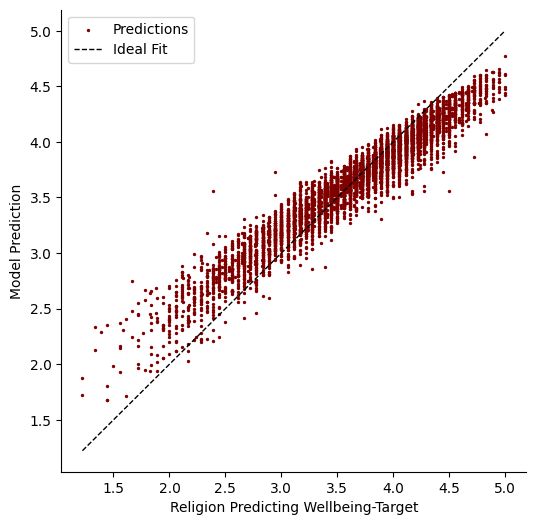

In [116]:
print_prediction(y_train, y_pred)

In [117]:
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred))
train_mae = mean_absolute_error(y_train, y_pred)
print("Training data prediction. RMSE: ", train_mse, " MAE: ",train_mae)

Training data prediction. RMSE:  0.042268874832318976  MAE:  0.15994737742656254


In [118]:
y_pred_test = rf_model.predict(x_test)


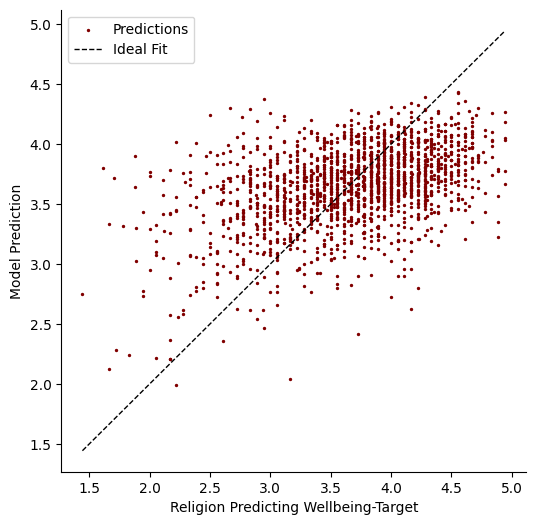

In [119]:
print_prediction(y_test, y_pred_test)

In [120]:
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mae = mean_absolute_error(y_test, y_pred_test)
print("Test data prediction. RMSE: ", test_mse, " MAE: ",test_mae)

Test data prediction. RMSE:  0.29816307004465914  MAE:  0.42759014351948255


[('denomination_Muslim (Azhari)', 8.240160376232259e-06), ('denomination_Jain', 1.1039181942613753e-05), ('denomination_Shinto', 3.8108781544238575e-05), ('ethnicity_Pacific Islander', 5.965269872943492e-05), ('denomination_Muslim (Alevi)', 8.03075315650984e-05), ('ethnicity_Malay', 0.00012010827019632747), ('ethnicity_Armenian', 0.00023378153047940136), ('denomination_Christian', 0.00028519043586226224), ('ethnicity_Indigenous', 0.0003879998533606793), ('ethnicity_Kurdish', 0.00041376721552258865), ('denomination_Druze', 0.0004185429533672781), ('denomination_Taoist', 0.00048435882433140576), ('denomination_African religions', 0.0004980529288559792), ('denomination_Muslim (non-sectarian)', 0.0006451753951933122), ('ethnicity_Indian', 0.0008178832631434486), ('denomination_Spiritist', 0.0012571706499854248), ('denomination_Hindu', 0.0018021285067405083), ('denomination_Buddhist', 0.00206973414239318), ('ethnicity_South Asian', 0.0021856827920947956), ('ethnicity_African', 0.00268026253

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53],
 [Text(0, 0, 'rel_1'),
  Text(1, 0, 'rel_2'),
  Text(2, 0, 'rel_3'),
  Text(3, 0, 'rel_4'),
  Text(4, 0, 'rel_5'),
  Text(5, 0, 'rel_6'),
  Text(6, 0, 'rel_7'),
  Text(7, 0, 'rel_8'),
  Text(8, 0, 'rel_9'),
  Text(9, 0, 'cnorm_1'),
  Text(10, 0, 'cnorm_2'),
  Text(11, 0, 'age'),
  Text(12, 0, 'ses'),
  Text(13, 0, 'education'),
  Text(14, 0, 'gender_man'),
  Text(15, 0, 'gender_other'),
  Text(16, 0, 'gender_woman'),
  Text(17, 0, 'ethnicity_African'),
  Text(18, 0, 'ethnicity_Armenian'),
  Text(19, 0, 'ethnicity_Asian'),
  Text(20, 0, 'ethnicity_Caucasian/European'),
  Text(21, 0, 'ethnicity_Chinese'),
  Text(22, 0, 'ethnicity_East Asian'),
  Text(23, 0, 'ethnicity_I would ra

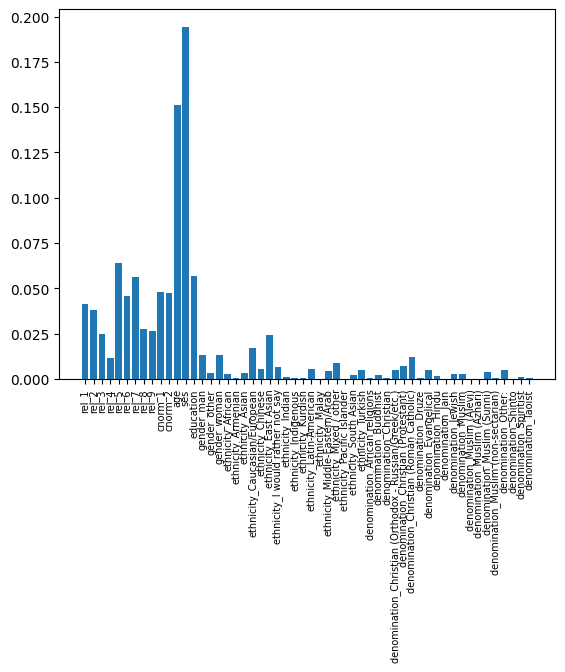

In [121]:
varnames = list(x_train.columns)
features = rf_model.feature_importances_
feature_numbers = sorted(list(zip(varnames, features)),key = lambda x: x[1])

print(feature_numbers)

plt.bar(varnames, features)
plt.xticks(fontsize = 7, rotation = 90)

The model returned a RMSE of 0.29 and 0.43 against the test(validation) data. The most important features in predicting well-being seem to be socioeconomic status, age, and belief in a God or Gods. Socioeconomic status predicting wellbeing better than believing in a god leads me to believe it should be excluded from the model. It may be wise to determine how socioeconomic status is correlated with any religious responses.

Possible ways to improve the model:
Use parameters of RandomForest 
Tune hyperparameters of RandomForest
Remove less important/informative features from model and rerun regression



Princess' Linear Regression model and Decision Tree

In [122]:
religious_df = pd.read_csv("train_data.csv", delimiter = ";")

In [123]:
train_x_data = religious_df[['rel_1', 'rel_2', 'rel_3', 'rel_4', 'rel_5', 'rel_6', 'rel_7', 'rel_8', 'rel_9', 'cnorm_1', 'cnorm_2', 'education']]
train_y_data= religious_df[['wb_gen_1', 'wb_gen_2', 'wb_phys_1', 'wb_phys_1', 'wb_phys_2', 'wb_phys_3', 'wb_phys_4', 'wb_phys_5', 'wb_phys_6', 'wb_phys_7', 'wb_psych_1', 'wb_psych_2', 'wb_psych_3', 'wb_psych_4', 'wb_psych_5', 'wb_psych_6', 'wb_soc_1', 'wb_soc_2', 'wb_soc_3', 'wb_phys_mean', 'wb_psych_mean', 'wb_soc_mean']]
train_y_data = religious_df[['wb_overall_mean']]

In [124]:
train_x, test_x, train_y, test_y = train_test_split(train_x_data, train_y_data, test_size = 0.2, random_state = 42)

In [125]:
## Running a linear regression
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(train_x, train_y)

linear_model.coef_

array([[ 0.18595545, -0.08733665,  0.06922404,  0.0518031 ,  0.01746139,
         0.00146142, -0.0325347 , -0.0363008 ,  0.05481957,  0.04082057,
         0.02325776,  0.07180272]])

In [126]:
y_pred = linear_model.predict(train_x)
y_pred

array([[3.62285283],
       [3.63093774],
       [3.5676143 ],
       ...,
       [3.59133283],
       [3.64525606],
       [3.98676161]])

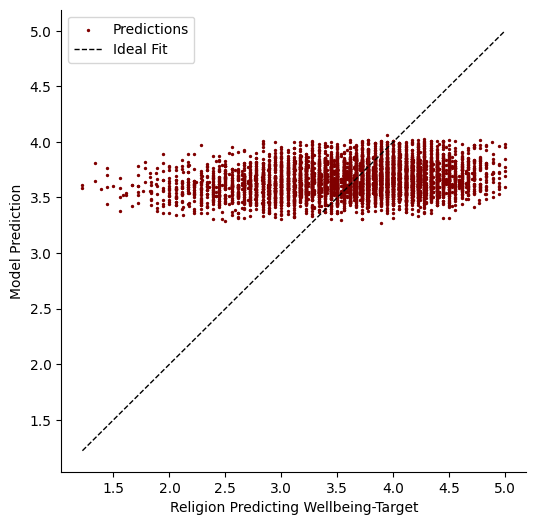

In [127]:
print_prediction(train_y, y_pred)

In [128]:
linear_model = LinearRegression()
linear_model.fit(test_x, test_y)

linear_model.coef_

array([[ 0.17801936, -0.02290951,  0.00305599,  0.06542202, -0.04863688,
         0.11149086, -0.08488763,  0.1003964 , -0.03613921, -0.10289085,
         0.15825691,  0.08635717]])

In [129]:

y_pred = linear_model.predict(test_x)
y_pred

array([[3.76095701],
       [3.75091541],
       [3.3458303 ],
       ...,
       [3.49024876],
       [3.94188143],
       [4.09605261]])

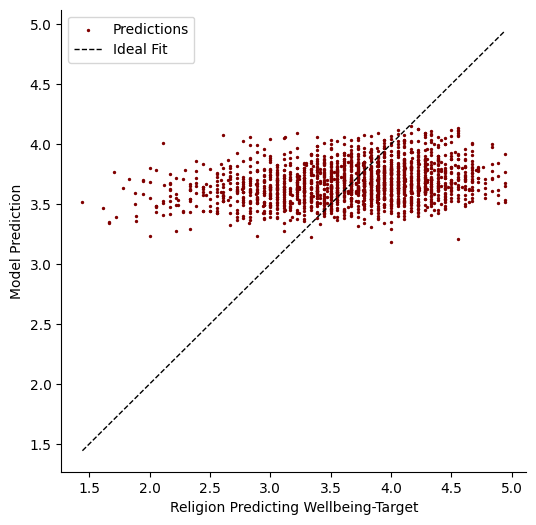

In [130]:
print_prediction(test_y, y_pred)

Model does not learn from a linear regression model - not a very good fit

In [131]:
religious_cat_dummies = pd.get_dummies(religious_df)
religious_cat_dummies
pd.set_option('display.max_columns', None)
display(religious_cat_dummies)


,subject,rel_1,rel_2,rel_3,rel_4,rel_5,rel_6,rel_7,rel_8,rel_9,cnorm_1,cnorm_2,wb_gen_1,wb_gen_2,wb_phys_1,wb_phys_2,wb_phys_3,wb_phys_4,wb_phys_5,wb_phys_6,wb_phys_7,wb_psych_1,wb_psych_2,wb_psych_3,wb_psych_4,wb_psych_5,wb_psych_6,wb_soc_1,wb_soc_2,wb_soc_3,wb_overall_mean,wb_phys_mean,wb_psych_mean,wb_soc_mean,age,ses,education,gdp,gdp_scaled,attention_check,country_Australia,country_Belgium,country_Brazil,country_Canada,country_Chile,country_China,country_Croatia,country_Denmark,country_France,country_Germany,country_India,country_Ireland,country_Israel,country_Italy,country_Japan,country_Lithuania,country_Morocco,country_Netherlands,country_Romania,country_Singapore,country_Spain,country_Turkey,country_UK,country_US,gender_man,gender_other,gender_woman,ethnicity_African,ethnicity_Armenian,ethnicity_Asian,ethnicity_Caucasian/European,ethnicity_Chinese,ethnicity_East Asian,ethnicity_I would rather not say,ethnicity_Indian,ethnicity_Indigenous,ethnicity_Kurdish,ethnicity_Latin-American,ethnicity_Malay,ethnicity_Middle-Eastern/Arab,ethnicity_Mixed / other,ethnicity_Pacific Islander,ethnicity_South Asian,ethnicity_Turkish,denomination_African religions,denomination_Buddhist,denomination_Christian,denomination_Christian (Orthodox - Russian/Greek/etc.),denomination_Christian (Protestant),denomination_Christian (Roman Catholic),denomination_Druze,denomination_Evangelical,denomination_Hindu,denomination_Jain,denomination_Jewish,denomination_Muslim,denomination_Muslim (Alevi),denomination_Muslim (Azhari),denomination_Muslim (Sunni),denomination_Muslim (non-sectarian),denomination_Other:,denomination_Shinto,denomination_Spiritist,denomination_Taoist,sample_type_general public,sample_type_mixed,sample_type_online panel,sample_type_students,compensation_course credit,compensation_monetary reward,compensation_no compensation,compensation_no compensation + course credit,compensation_raffle
0,5362,0.833333,0.857143,1.0,1,0.833333,0.833333,1.000000,1.00,1.00,0.75,1.00,4,5,5,4,5,5,4,4,5,5,4,4,2,3,3,3,5,1.0,3.944444,4.571429,3.500000,3.000000,20.0,6.0,4,78806.431996,1.973267,1,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False
1,10070,0.000000,0.000000,0.0,0,0.166667,0.166667,0.166667,0.00,0.00,0.50,0.50,4,4,5,4,3,5,4,4,4,3,3,3,4,3,3,2,2,4.0,3.555556,4.142857,3.166667,2.666667,22.0,5.0,3,42491.364435,0.332479,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False
2,9515,0.000000,0.000000,0.5,0,0.000000,0.500000,0.000000,0.00,0.00,0.75,0.75,3,4,5,5,4,3,3,3,2,3,3,3,4,3,3,2,2,3.0,3.222222,3.571429,3.166667,2.333333,42.0,6.0,5,9311.366117,-1.166661,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False
3,5960,0.500000,0.428571,0.5,0,0.166667,0.500000,0.666667,0.25,0.25,0.75,0.75,4,4,5,5,4,5,5,5,5,4,4,4,5,5,3,5,4,NaN,4.470588,4.857143,4.166667,4.500000,24.0,7.0,4,41613.998082,0.292837,1,False,False,False,False,False,False,Fals

In [132]:
#religious_cat_dummies = religious_cat_dummies.drop("compensation_no")

In [133]:
from sklearn import tree

religious_tree = tree.DecisionTreeRegressor()
religious_tree = religious_tree.fit(train_x, train_y)
y_pred = religious_tree.predict(train_x)

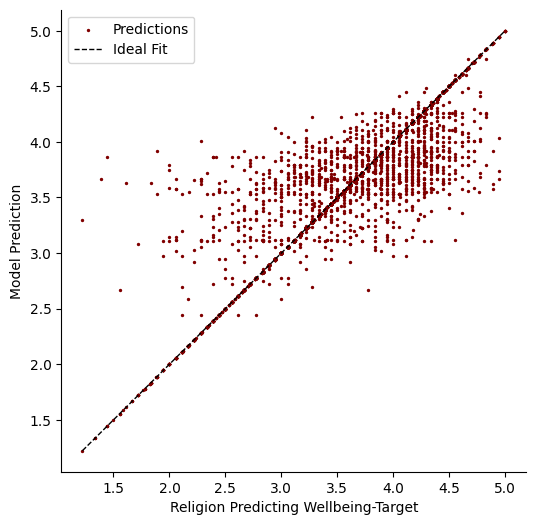

In [134]:
print_prediction(train_y, y_pred)

In [135]:
religious_tree = tree.DecisionTreeRegressor()
religious_tree = religious_tree.fit(test_x, test_y)
y_pred_ = religious_tree.predict(test_x)

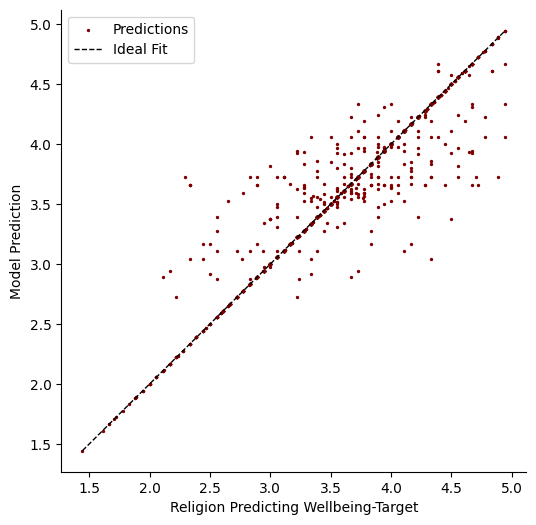

In [136]:
print_prediction(test_y, y_pred_)

Model does not learn from my decision trees model - not a very good fit